# 07: Transfer DiD Report Workflow

This notebook turns the previous pieces into a short applied DiD
report. The case: some clinics extend evening hours starting in
month 10. The outcome is average wait time in minutes.


In [1]:
from lite_setup import ensure_packages
await ensure_packages()

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf

from checks import check_close, check_columns, check_same_estimate, check_sign
from did_utils import (
    did_2x2_table,
    manual_did,
    predicted_values_2x2,
    plot_group_trends,
    plot_did_counterfactual,
    make_event_dummies,
    extract_event_study_results,
    plot_event_study,
)


plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("data")


Running outside JupyterLite; assuming packages are already installed.


In [2]:
df = pd.read_csv(DATA_DIR / "did_capstone_case.csv")
print(check_columns(df, ["clinic_id", "month", "treated_clinic", "post", "did", "wait_minutes", "patient_volume", "staff_count"]))
df.head()


Correct: all required columns are present.


,clinic_id,month,treated_clinic,post,did,wait_minutes,patient_volume,staff_count,region
0,C01,1,1,0,0,29.62,399.0,12,North
1,C01,2,1,0,0,33.40,444.0,11,North
2,C01,3,1,0,0,35.86,510.0,11,North
3,C01,4,1,0,0,33.21,487.0,11,North
4,C01,5,1,0,0,31.99,500.0,11,North


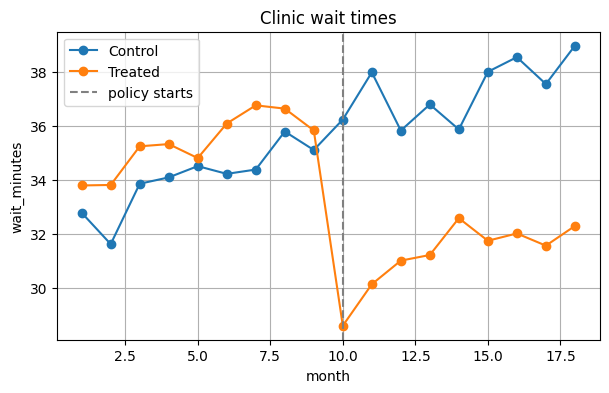

In [3]:
plot_group_trends(df, "wait_minutes", "month", "treated_clinic", title="Clinic wait times")
plt.axvline(10, color="gray", linestyle="--", label="policy starts")
plt.legend()
plt.show()


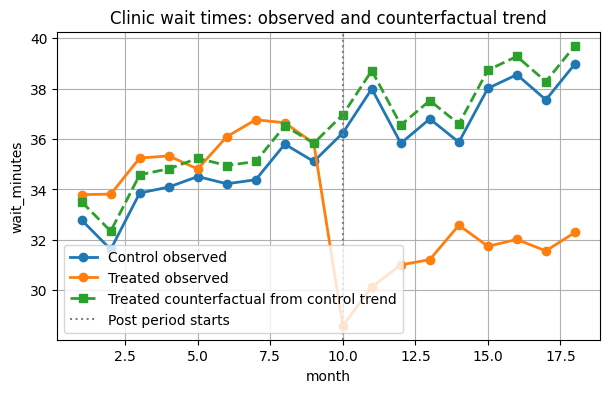

In [4]:
plot_did_counterfactual(
    df,
    "wait_minutes",
    "month",
    treated_col="treated_clinic",
    post_col="post",
    title="Clinic wait times: observed and counterfactual trend",
)
plt.show()


In [5]:
simple = smf.ols("wait_minutes ~ treated_clinic * post", data=df).fit()
fe = smf.ols(
    "wait_minutes ~ did + C(clinic_id) + C(month)",
    data=df,
).fit(cov_type="cluster", cov_kwds={"groups": df["clinic_id"]})
fe_patient_volume = smf.ols(
    "wait_minutes ~ did + patient_volume + C(clinic_id) + C(month)",
    data=df,
).fit(cov_type="cluster", cov_kwds={"groups": df["clinic_id"]})
bad_control_model = smf.ols(
    "wait_minutes ~ did + patient_volume + staff_count + C(clinic_id) + C(month)",
    data=df,
).fit(cov_type="cluster", cov_kwds={"groups": df["clinic_id"]})

pd.DataFrame(
    {
        "estimate": [
            simple.params["treated_clinic:post"],
            fe.params["did"],
            fe_patient_volume.params["did"],
            bad_control_model.params["did"],
        ],
        "std_error": [
            simple.bse["treated_clinic:post"],
            fe.bse["did"],
            fe_patient_volume.bse["did"],
            bad_control_model.bse["did"],
        ],
    },
    index=[
        "simple 2x2 regression",
        "clinic and month FE",
        "FE + patient volume",
        "FE + patient volume + staff count (bad-control sensitivity)",
    ],
)


,estimate,std_error
simple 2x2 regression,-7.399630,0.891886
clinic and month FE,-7.399630,0.370967
FE + patient volume,-7.310922,0.366260
FE + patient volume + staff count (bad-control sensitivity),-6.054455,0.369185


`patient_volume` is a reasonable time-varying adjustment in
this synthetic case because it is not generated as a result of
the policy. `staff_count` is different: extended hours can
change staffing, so controlling for `staff_count` may block part
of the policy pathway. Treat the staffing model as a
bad-control sensitivity, not the main causal specification. The
reported main estimate below uses the fixed-effects model with
patient volume only, so it is closer to the total effect of
extended hours on wait time.


In [6]:
estimate = fe_patient_volume.params["did"]
se = fe_patient_volume.bse["did"]
ci = (estimate - 1.96 * se, estimate + 1.96 * se)

print(f"Estimated effect: {estimate:.2f} wait minutes")
print(f"Clustered SE:     {se:.2f}")
print(f"Approx 95% CI:    ({ci[0]:.2f}, {ci[1]:.2f})")
print(check_sign(estimate, expected="negative", label="extended-hours estimate"))


Estimated effect: -7.31 wait minutes
Clustered SE:     0.37
Approx 95% CI:    (-8.03, -6.59)
Correct: extended-hours estimate is negative.


## Report template

1. Research question
2. Data structure
3. Treatment and comparison groups
4. Outcome variable
5. Identification assumption
6. Model specification
7. Main estimate
8. Visualization or pre-trend evidence
9. Robustness or placebo check
10. Limitations
11. Conclusion

Write-up checkpoint: in 3-5 sentences, explain whether the DiD
estimate supports the claim that extended hours changed wait
times. Mention the unit of the coefficient, the comparison being
made, and at least one threat to validity.
